## 1. Install

In [3]:
# Latest release from PyPI:
# !pip install quanallo

# Or, for development:
# !pip install -e ../   # from the repo root

In [4]:
# Alternative: load preprocessed data
import pandas as pd, numpy as np
from quanallo import ProteinGraph

def _build_weighted(edges_df, N):
    A = np.zeros((N, N))
    for _, r in edges_df.iterrows():
        i, j = int(r['i']), int(r['j']); w = float(r['weight'])
        A[i, j] = w; A[j, i] = w
    return A

DATA = "input_BCR_ABL1"  # adjust to your path

apo_nodes = pd.read_csv(f"{DATA}/apo_nodes.csv")
apo_edges = pd.read_csv(f"{DATA}/apo_edges.csv")
apo_A_bin = np.load(f"{DATA}/apo_adjacency.npy").astype(float)
apo_A_w   = _build_weighted(apo_edges, len(apo_nodes))

key = apo_nodes.set_index(['chain','resnum'])['idx']
def _to_idx(df):
    return np.array([int(key.loc[(r.chain, int(r.resnum))]) for _, r in df.iterrows()
                     if (r.chain, int(r.resnum)) in key.index])

apo = ProteinGraph(
    nodes=apo_nodes,
    adjacency_binary=apo_A_bin,
    adjacency_weighted=apo_A_w,
    active_idx=_to_idx(pd.read_csv(f"{DATA}/apo_active_site.csv")),
    ground_truth_idx=_to_idx(pd.read_csv(f"{DATA}/holo_ground_truth.csv")),
    name="BCR_ABL1_APO",
)
print(apo)

ProteinGraph(name='BCR_ABL1_APO', N=451, |active|=21, |GT|=20)


## 3. Predict allosteric residues with a single line

The `AllostericPredictor` is your one-stop shop. Default settings already use the best single method we found in benchmarks (`dqaw_lifetime` — see notebook #2 for the comparison).

In [5]:
from quanallo import AllostericPredictor

predictor = AllostericPredictor(method="dqaw_lifetime", top_k=5)
result = predictor.predict(apo)

print(result)
print()
print("Top-5 residues:")
for rank, hit in enumerate(result.top_residues, start=1):
    print(f"  {rank}. {hit['chain']}{hit['resnum']:>3} {hit['resname']}")

PredictionResult(method='dqaw_lifetime', top-5 = A176,A175,A129,A216,A178, weighted_top5=0.203)

Top-5 residues:
  1. A176 SER
  2. A175 SER
  3. A129 TRP
  4. A216 GLU
  5. A178 GLY


## 4. (Optional) Compare against a HOLO ground truth

If a holo structure with a known allosteric drug is available, we can use it to *score* the prediction. The HOLO ligand (Sotorasib, residue `MOV`) defines the ground-truth pocket; we measure how close our top-5 predictions are.

In [6]:
# Build the holo graph with ground truth
holo_nodes = pd.read_csv(f"{DATA}/holo_nodes.csv")
holo_edges = pd.read_csv(f"{DATA}/holo_edges.csv")
holo_A_bin = np.load(f"{DATA}/holo_adjacency.npy").astype(float)
holo_A_w   = _build_weighted(holo_edges, len(holo_nodes))
key_h = holo_nodes.set_index(['chain','resnum'])['idx']
def _to_idx_h(df):
    return np.array([int(key_h.loc[(r.chain, int(r.resnum))]) for _, r in df.iterrows()
                     if (r.chain, int(r.resnum)) in key_h.index])

holo = ProteinGraph(
    nodes=holo_nodes, adjacency_binary=holo_A_bin, adjacency_weighted=holo_A_w,
    active_idx=_to_idx_h(pd.read_csv(f"{DATA}/apo_active_site.csv")),
    ground_truth_idx=_to_idx_h(pd.read_csv(f"{DATA}/holo_ground_truth.csv")),
    name="KRAS_G12C_HOLO",
)

# Run the same predictor on HOLO graph
result = predictor.predict(holo)
print(result)
print()
print(f"Weighted top-5 (fuzzy GT credit, max=5.0): {result.weighted_top5:.3f}")
print(f"Precision@5 by hop tolerance:")
for k, p in result.precision_at_k.items():
    print(f"  k={k} hops:  {p:.0%}")

PredictionResult(method='dqaw_lifetime', top-5 = A223,A199,A197,A227,A196, weighted_top5=0.086)

Weighted top-5 (fuzzy GT credit, max=5.0): 0.086
Precision@5 by hop tolerance:
  k=0 hops:  0%
  k=1 hops:  0%
  k=2 hops:  0%
  k=3 hops:  0%
  k=4 hops:  0%
  k=5 hops:  20%


## 5. Inspect the hit list as a DataFrame

Every `PredictionResult` knows how to convert itself into a tidy table:

In [7]:
df = result.to_dataframe()
print(df)

   idx chain  resnum resname  hop_to_gt    credit
0  140     A     223     THR          6  0.015625
1  116     A     199     SER          7  0.007813
2  114     A     197     THR          6  0.015625
3  144     A     227     GLY          6  0.015625
4  113     A     196     ASN          5  0.031250


## 6. Visualize on the 3D structure

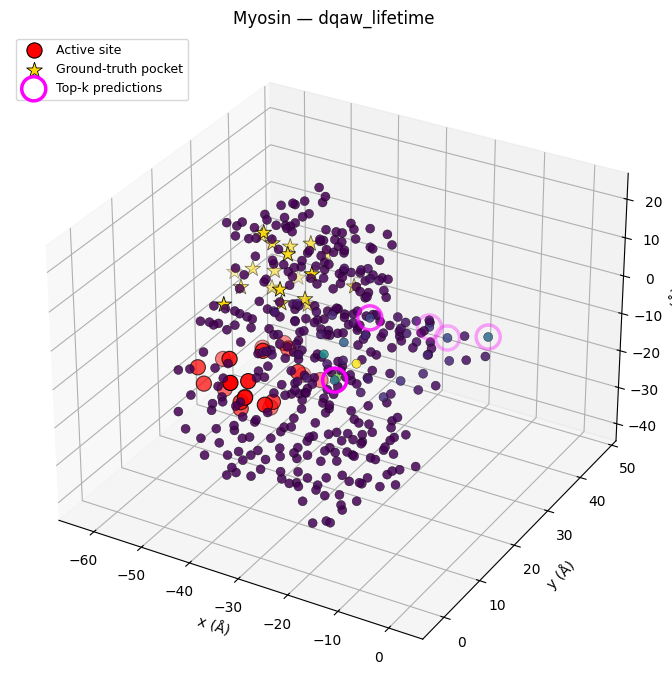

In [8]:
import matplotlib.pyplot as plt
from quanallo.visualization import plot_scores_3d

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
plot_scores_3d(
    holo, result.scores, top_indices=result.top_indices,
    title=f"Myosin — {result.method_used}", ax=ax,
)
plt.tight_layout()
plt.show()

## 7. Next steps

You have just built and scored an allosteric pocket predictor in 20 lines of code. Next:

- **Notebook 02 — methods deep dive**: compare all 9 prediction methods on KRAS.
- **Notebook 03 — QuanAnt machines**: ant colonies and APO→HOLO transfer learning.

For a **one-liner** that does PDB → prediction in a single call:

```python
predictor = AllostericPredictor(method="dqaw_lifetime")
result = predictor.predict_from_pdb(
    apo_pdb="4OBE.pdb",
    holo_pdb="6OIM.pdb",            # optional, for scoring
    auto_active_site_ligand="GDP",
    holo_drug_name="MOV",            # for ground-truth detection
    top_k=5,
)
print(result)
```